# Composer Classification — Hyperparameter-Tuned Evaluation (Combined Dataset)

Rebased companion to `Composer_Classification_Evaluation.ipynb` (the untuned baseline, itself
rebased against the team's combined-dataset pipeline). This notebook:

1. Runs a **Keras Tuner Hyperband search** over the team's new CNN/LSTM architecture (search uses
   only the validation/`dev` split — the test set is never touched during tuning).
2. Retrains the best configuration found for each model with the team's full training budget
   (60 epochs, full-batch).
3. Reruns the entire evaluation + documentation suite from the baseline notebook on the tuned
   models.
4. Adds a tuned vs. untuned comparison table against the freshly-updated baseline notebook's
   `evaluation_outputs/`.

Data loading (the team's `combined_{train,dev,test}_features.csv`, pre-assigned splits, no
re-splitting) and the base CNN/LSTM architecture are identical to the baseline notebook — only
the hyperparameters are searched.

In [1]:
# If a package is missing, run the relevant line below once, then restart the kernel:
# %pip install tensorflow pandas scikit-learn matplotlib seaborn joblib shap keras-tuner

import json
import os
import random
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
from tensorflow.keras.regularizers import l2

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path('evaluation_outputs_tuned')
OUTPUT_DIR.mkdir(exist_ok=True)
BASELINE_OUTPUT_DIR = Path('evaluation_outputs')

print('TensorFlow:', tf.__version__)
print('Keras Tuner:', kt.__version__)

TensorFlow: 2.21.0
Keras Tuner: 1.4.8


## 1. Load the combined, pre-split data

In [2]:
def find_csv(filename):
    candidates = [
        Path(filename),
        Path('data') / 'features' / filename,
        Path('..') / 'data' / 'features' / filename,
        Path('..') / '..' / 'data' / 'features' / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    for pattern_root in [Path('.'), Path('..'), Path('../..')]:
        matches = list(pattern_root.rglob(filename))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'Could not locate {filename}')

TARGET = 'composer'
IDENTIFIERS = ['filename', 'relative_path']

train_path = find_csv('combined_train_features.csv')
dev_path = find_csv('combined_dev_features.csv')
test_path = find_csv('combined_test_features.csv')

df_train = pd.read_csv(train_path)
df_val = pd.read_csv(dev_path)
df_test = pd.read_csv(test_path)

print('Loaded from:', train_path, '|', dev_path, '|', test_path)
print('Shapes (train/val/test):', df_train.shape, df_val.shape, df_test.shape)

label_encoder = LabelEncoder()
label_encoder.fit(df_train[TARGET].astype(str))
class_names = label_encoder.classes_
n_classes = len(class_names)
classes_arr = np.arange(n_classes)

y_train = label_encoder.transform(df_train[TARGET].astype(str))
y_val = label_encoder.transform(df_val[TARGET].astype(str))
y_test = label_encoder.transform(df_test[TARGET].astype(str))

numeric_cols = df_train.drop(columns=[TARGET, *IDENTIFIERS]).select_dtypes(include='number').columns.tolist()
train_variances = df_train[numeric_cols].var(axis=0)
feature_columns = train_variances[train_variances > 0].index.tolist()
constant_columns = train_variances[train_variances == 0].index.tolist()

scaler = StandardScaler()
X_train_2d = scaler.fit_transform(df_train[feature_columns].astype('float32')).astype('float32')
X_val_2d = scaler.transform(df_val[feature_columns].astype('float32')).astype('float32')
X_test_2d = scaler.transform(df_test[feature_columns].astype('float32')).astype('float32')

print('Classes:', class_names.tolist())
print('Split sizes (train/val/test):', len(y_train), len(y_val), len(y_test))
print('Retained features:', len(feature_columns))
print('Removed constants:', constant_columns)

Loaded from: ..\data\features\combined_train_features.csv | ..\data\features\combined_dev_features.csv | ..\data\features\combined_test_features.csv
Shapes (train/val/test): (1550, 63) (351, 63) (338, 63)
Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
Split sizes (train/val/test): 1550 351 338
Retained features: 58
Removed constants: ['gm_ethnic_track_count', 'gm_sound_effects_track_count']


In [3]:
n_features = X_train_2d.shape[1]

X_train_cnn = X_train_2d[..., np.newaxis]
X_val_cnn = X_val_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

X_train_lstm = X_train_2d.reshape(-1, 1, n_features)
X_val_lstm = X_val_2d.reshape(-1, 1, n_features)
X_test_lstm = X_test_2d.reshape(-1, 1, n_features)

cnn_reshape = lambda arr: arr[..., np.newaxis]
lstm_reshape = lambda arr: arr.reshape(-1, 1, n_features)

balanced = compute_class_weight('balanced', classes=classes_arr, y=y_train)
class_weights = {int(i): float(w) for i, w in zip(classes_arr, balanced)}

print('CNN shape:', X_train_cnn.shape)
print('LSTM shape:', X_train_lstm.shape)

CNN shape: (1550, 58, 1)
LSTM shape: (1550, 1, 58)


## 2. Hyperparameter search (Keras Tuner Hyperband)

Search space is centered on the team's new architecture (16 conv1 filters, 32 conv2 filters, 32
dense units, 0.3 dropout, lr 5e-3 for CNN; 32 LSTM units, 32 dense units, 0.3/0.2 dropout, lr 3e-3
for LSTM). Kernel sizes and the CNN's L2 regularization are kept fixed to match the team's design;
everything else is tunable. Selection is on `val_accuracy`; training here uses full-batch gradient
descent (`batch_size=len(X_train)`), matching the team's regime.

In [4]:
def build_cnn(hp):
    conv1_filters = hp.Choice('conv1_filters', [8, 16, 24, 32])
    conv2_filters = hp.Choice('conv2_filters', [16, 24, 32, 48])
    dense_units = hp.Choice('dense_units', [16, 32, 48, 64])
    dropout = hp.Float('dropout', 0.2, 0.5, step=0.1)
    learning_rate = hp.Choice('learning_rate', [1e-2, 5e-3, 1e-3])

    model = Sequential([
        Input(shape=(n_features, 1)),
        Conv1D(conv1_filters, kernel_size=5, padding='same', activation='relu', kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Conv1D(conv2_filters, kernel_size=3, padding='same', activation='relu'),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout),
        Dense(n_classes, activation='softmax'),
    ], name='composer_cnn_tuned')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

tuner_cnn = kt.Hyperband(
    build_cnn,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    seed=SEED,
    directory=str(OUTPUT_DIR / 'kt_search'),
    project_name='cnn',
    overwrite=True,
)
tuner_cnn.search(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    batch_size=len(X_train_cnn),
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1,
)

best_cnn_hp = tuner_cnn.get_best_hyperparameters(1)[0]
print('Best CNN hyperparameters:', best_cnn_hp.values)

Trial 30 Complete [00h 00m 09s]
val_accuracy: 0.7435897588729858

Best val_accuracy So Far: 0.8803418874740601
Total elapsed time: 00h 01m 32s
Best CNN hyperparameters: {'conv1_filters': 8, 'conv2_filters': 48, 'dense_units': 48, 'dropout': 0.30000000000000004, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0023'}


In [5]:
def build_lstm(hp):
    lstm_units = hp.Choice('lstm_units', [16, 32, 48, 64])
    dropout1 = hp.Float('dropout1', 0.2, 0.4, step=0.05)
    dense_units = hp.Choice('dense_units', [16, 32, 48])
    dropout2 = hp.Float('dropout2', 0.1, 0.3, step=0.05)
    learning_rate = hp.Choice('learning_rate', [1e-2, 5e-3, 3e-3, 1e-3])

    model = Sequential([
        Input(shape=(1, n_features)),
        LSTM(lstm_units),
        Dropout(dropout1),
        Dense(dense_units, activation='relu'),
        Dropout(dropout2),
        Dense(n_classes, activation='softmax'),
    ], name='composer_lstm_tuned')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

tuner_lstm = kt.Hyperband(
    build_lstm,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    seed=SEED,
    directory=str(OUTPUT_DIR / 'kt_search'),
    project_name='lstm',
    overwrite=True,
)
tuner_lstm.search(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    batch_size=len(X_train_lstm),
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1,
)

best_lstm_hp = tuner_lstm.get_best_hyperparameters(1)[0]
print('Best LSTM hyperparameters:', best_lstm_hp.values)

Trial 30 Complete [00h 00m 04s]
val_accuracy: 0.7350427508354187

Best val_accuracy So Far: 0.8717948794364929
Total elapsed time: 00h 02m 15s


Best LSTM hyperparameters: {'lstm_units': 64, 'dropout1': 0.30000000000000004, 'dense_units': 32, 'dropout2': 0.15000000000000002, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


## 3. Retrain the best configuration with the full training budget

60 epochs, full-batch, `EarlyStopping`/`ReduceLROnPlateau` matching the team's/baseline notebook's
training regime, so a complete history is available for the curves later.

In [6]:
def callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5),
    ]

cnn_model = tuner_cnn.hypermodel.build(best_cnn_hp)
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=60,
    batch_size=len(X_train_cnn),
    class_weight=class_weights,
    callbacks=callbacks(),
    verbose=1,
)

with open(OUTPUT_DIR / 'best_hyperparameters_cnn.json', 'w') as f:
    json.dump(best_cnn_hp.values, f, indent=2)

Epoch 1/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.2284 - loss: 1.4214

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2284 - loss: 1.4214 - val_accuracy: 0.5840 - val_loss: 1.1370 - learning_rate: 0.0100


Epoch 2/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4897 - loss: 1.1994

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9729 - loss: 0.1061

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9729 - loss: 0.1061 - val_accuracy: 0.8889 - val_loss: 0.4286 - learning_rate: 0.0050


Epoch 39/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9703 - loss: 0.1040

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9703 - loss: 0.1040 - val_accuracy: 0.8946 - val_loss: 0.4174 - learning_rate: 0.0050


In [7]:
lstm_model = tuner_lstm.hypermodel.build(best_lstm_hp)
lstm_history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_val_lstm, y_val),
    epochs=60,
    batch_size=len(X_train_lstm),
    class_weight=class_weights,
    callbacks=callbacks(),
    verbose=1,
)

with open(OUTPUT_DIR / 'best_hyperparameters_lstm.json', 'w') as f:
    json.dump(best_lstm_hp.values, f, indent=2)

Epoch 1/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2735 - loss: 1.3960

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2735 - loss: 1.3960 - val_accuracy: 0.6325 - val_loss: 1.2529 - learning_rate: 0.0100


Epoch 2/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5652 - loss: 1.2648

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9574 - loss: 0.1129

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9574 - loss: 0.1129 - val_accuracy: 0.8917 - val_loss: 0.3418 - learning_rate: 0.0050


Epoch 50/60


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9594 - loss: 0.1194

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9594 - loss: 0.1194 - val_accuracy: 0.8917 - val_loss: 0.3407 - learning_rate: 0.0050


## 4. Classification report + confusion matrix — test vs. validation

In [8]:
def evaluate_split(name, model, X, y_true):
    probabilities = model.predict(X, verbose=0)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, predictions, average='macro', zero_division=0
    )
    result = {
        'model_split': name,
        'accuracy': accuracy_score(y_true, predictions),
        'macro_precision': precision,
        'macro_recall': recall,
        'macro_f1': f1,
    }
    print(f'\n{name}')
    print(classification_report(y_true, predictions, target_names=class_names, zero_division=0))
    return result, predictions, probabilities

eval_specs = [
    ('CNN-test', cnn_model, X_test_cnn, y_test),
    ('CNN-val', cnn_model, X_val_cnn, y_val),
    ('LSTM-test', lstm_model, X_test_lstm, y_test),
    ('LSTM-val', lstm_model, X_val_lstm, y_val),
]

eval_results = {}
for name, model, X, y_true in eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    eval_results[name] = {
        'result': result,
        'predictions': predictions,
        'probabilities': probabilities,
        'y_true': y_true,
    }

results_df = pd.DataFrame([v['result'] for v in eval_results.values()]).set_index('model_split')
results_df.to_csv(OUTPUT_DIR / 'test_vs_val_metrics.csv')
display(results_df.style.format('{:.3f}'))


CNN-test
              precision    recall  f1-score   support

        Bach       0.97      0.96      0.97       155
   Beethoven       0.88      0.82      0.85        78
      Chopin       0.83      0.87      0.85        45
      Mozart       0.78      0.85      0.82        60

    accuracy                           0.90       338
   macro avg       0.87      0.87      0.87       338
weighted avg       0.90      0.90      0.90       338


CNN-val
              precision    recall  f1-score   support

        Bach       0.93      0.95      0.94       153
   Beethoven       0.89      0.81      0.85        80
      Chopin       0.87      0.90      0.88        51
      Mozart       0.77      0.79      0.78        67

    accuracy                           0.88       351
   macro avg       0.86      0.86      0.86       351
weighted avg       0.88      0.88      0.88       351




LSTM-test
              precision    recall  f1-score   support

        Bach       0.94      0.93      0.94       155
   Beethoven       0.88      0.83      0.86        78
      Chopin       0.86      0.82      0.84        45
      Mozart       0.75      0.85      0.80        60

    accuracy                           0.88       338
   macro avg       0.86      0.86      0.86       338
weighted avg       0.88      0.88      0.88       338


LSTM-val
              precision    recall  f1-score   support

        Bach       0.94      0.95      0.95       153
   Beethoven       0.87      0.81      0.84        80
      Chopin       0.94      0.90      0.92        51
      Mozart       0.76      0.82      0.79        67

    accuracy                           0.89       351
   macro avg       0.88      0.87      0.87       351
weighted avg       0.89      0.89      0.89       351



,accuracy,macro_precision,macro_recall,macro_f1
model_split,,,,
CNN-test,0.896,0.866,0.875,0.870
CNN-val,0.880,0.864,0.863,0.863
LSTM-test,0.879,0.858,0.859,0.857
LSTM-val,0.889,0.878,0.872,0.875


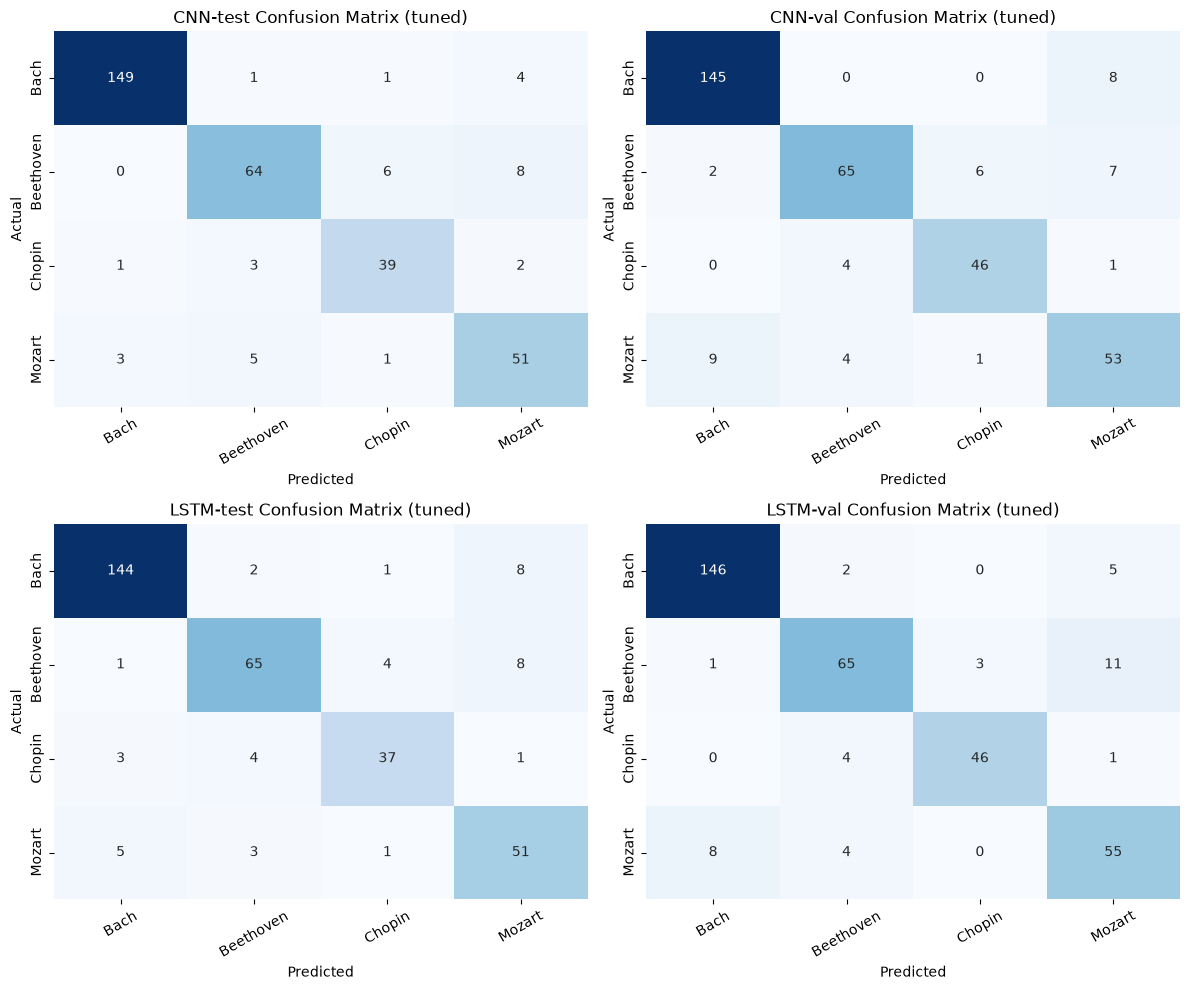

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [
    ('CNN-test', axes[0, 0]), ('CNN-val', axes[0, 1]),
    ('LSTM-test', axes[1, 0]), ('LSTM-val', axes[1, 1]),
]
for name, ax in layout:
    entry = eval_results[name]
    cm = confusion_matrix(entry['y_true'], entry['predictions'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set(title=f'{name} Confusion Matrix (tuned)', xlabel='Predicted', ylabel='Actual')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices_test_vs_val.png', dpi=150)
plt.show()

## 5. Loss & accuracy curves, with the final test score overlaid

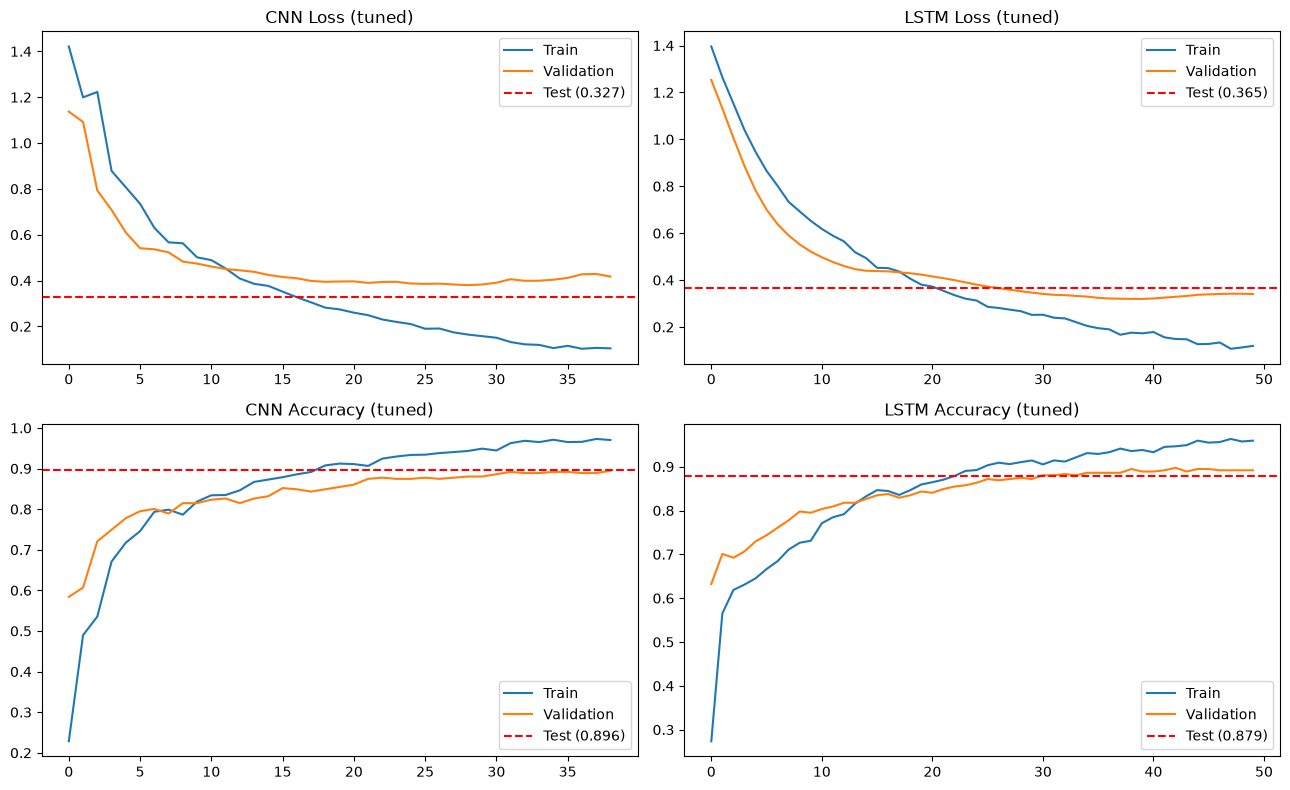

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
histories = [
    ('CNN', cnn_history, cnn_test_loss, cnn_test_acc),
    ('LSTM', lstm_history, lstm_test_loss, lstm_test_acc),
]
for col, (name, history, test_loss, test_acc) in enumerate(histories):
    axes[0, col].plot(history.history['loss'], label='Train')
    axes[0, col].plot(history.history['val_loss'], label='Validation')
    axes[0, col].axhline(test_loss, color='red', linestyle='--', label=f'Test ({test_loss:.3f})')
    axes[0, col].set_title(f'{name} Loss (tuned)')
    axes[0, col].legend()

    axes[1, col].plot(history.history['accuracy'], label='Train')
    axes[1, col].plot(history.history['val_accuracy'], label='Validation')
    axes[1, col].axhline(test_acc, color='red', linestyle='--', label=f'Test ({test_acc:.3f})')
    axes[1, col].set_title(f'{name} Accuracy (tuned)')
    axes[1, col].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'loss_accuracy_curves_with_test.png', dpi=150)
plt.show()

## 6. Multiclass ROC curves — test vs. validation

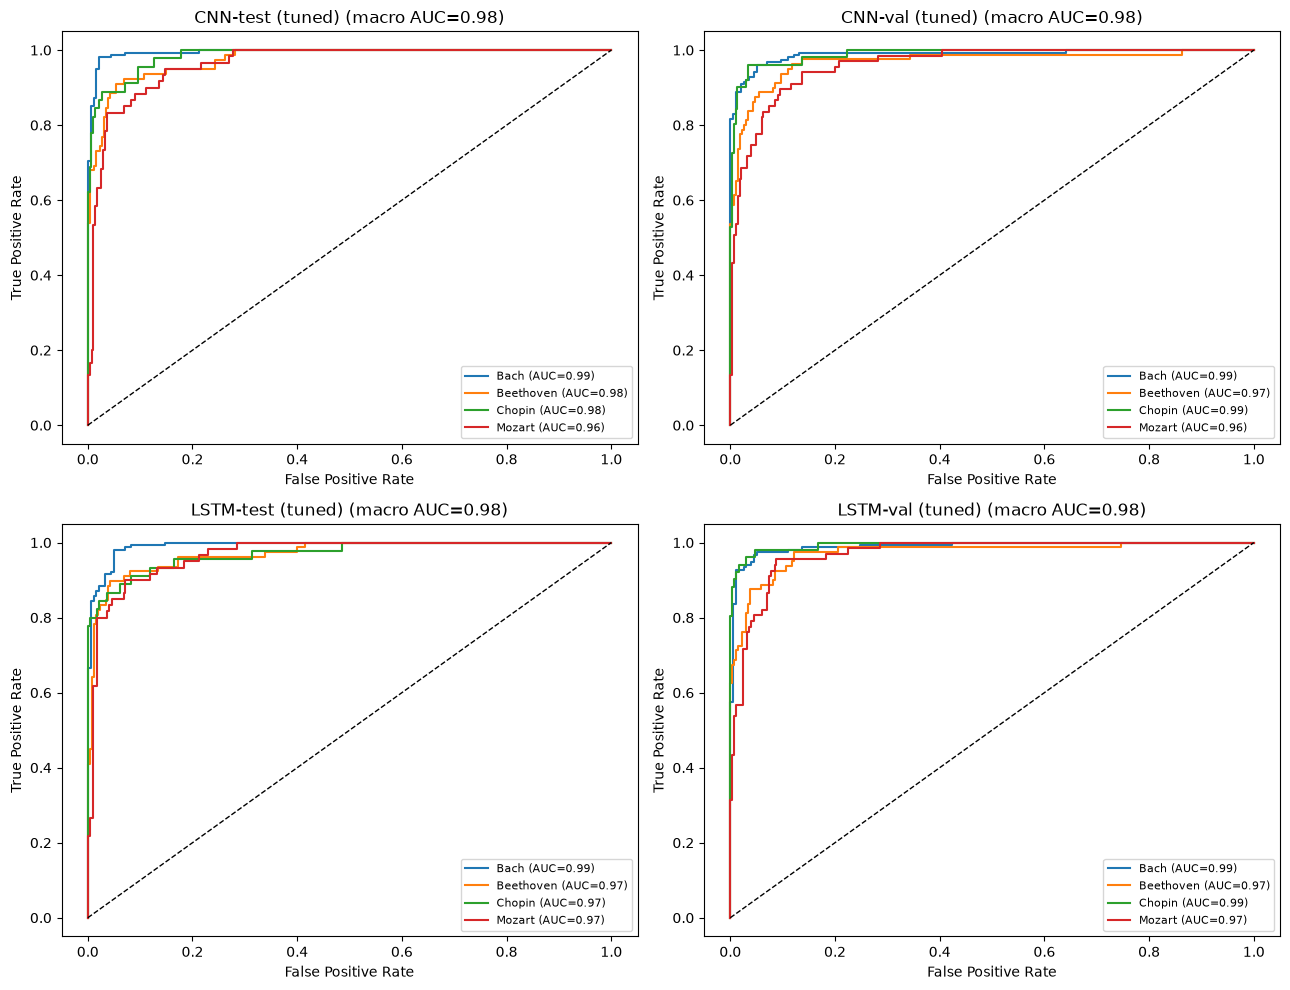

,Bach,Beethoven,Chopin,Mozart,macro_auc
model_split,,,,,
CNN-test,0.995,0.975,0.985,0.963,0.979
CNN-val,0.989,0.969,0.989,0.961,0.977
LSTM-test,0.992,0.970,0.971,0.968,0.975
LSTM-val,0.990,0.973,0.994,0.970,0.982


In [11]:
y_test_bin = label_binarize(y_test, classes=classes_arr)
y_val_bin = label_binarize(y_val, classes=classes_arr)

def plot_roc(ax, y_true_bin, probabilities, title):
    aucs = []
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f'{cls_name} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set(title=f'{title} (macro AUC={np.mean(aucs):.2f})', xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(fontsize=8)
    return aucs

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
roc_specs = [
    ('CNN-test', axes[0, 0], y_test_bin, eval_results['CNN-test']['probabilities']),
    ('CNN-val', axes[0, 1], y_val_bin, eval_results['CNN-val']['probabilities']),
    ('LSTM-test', axes[1, 0], y_test_bin, eval_results['LSTM-test']['probabilities']),
    ('LSTM-val', axes[1, 1], y_val_bin, eval_results['LSTM-val']['probabilities']),
]
roc_auc_records = []
for name, ax, y_bin, probs in roc_specs:
    aucs = plot_roc(ax, y_bin, probs, f'{name} (tuned)')
    roc_auc_records.append({'model_split': name, **{cls: a for cls, a in zip(class_names, aucs)}, 'macro_auc': np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_test_vs_val.png', dpi=150)
plt.show()

roc_auc_df = pd.DataFrame(roc_auc_records).set_index('model_split')
roc_auc_df.to_csv(OUTPUT_DIR / 'roc_auc_test_vs_val.csv')
display(roc_auc_df.style.format('{:.3f}'))

## 7. Permutation feature importance — test vs. validation

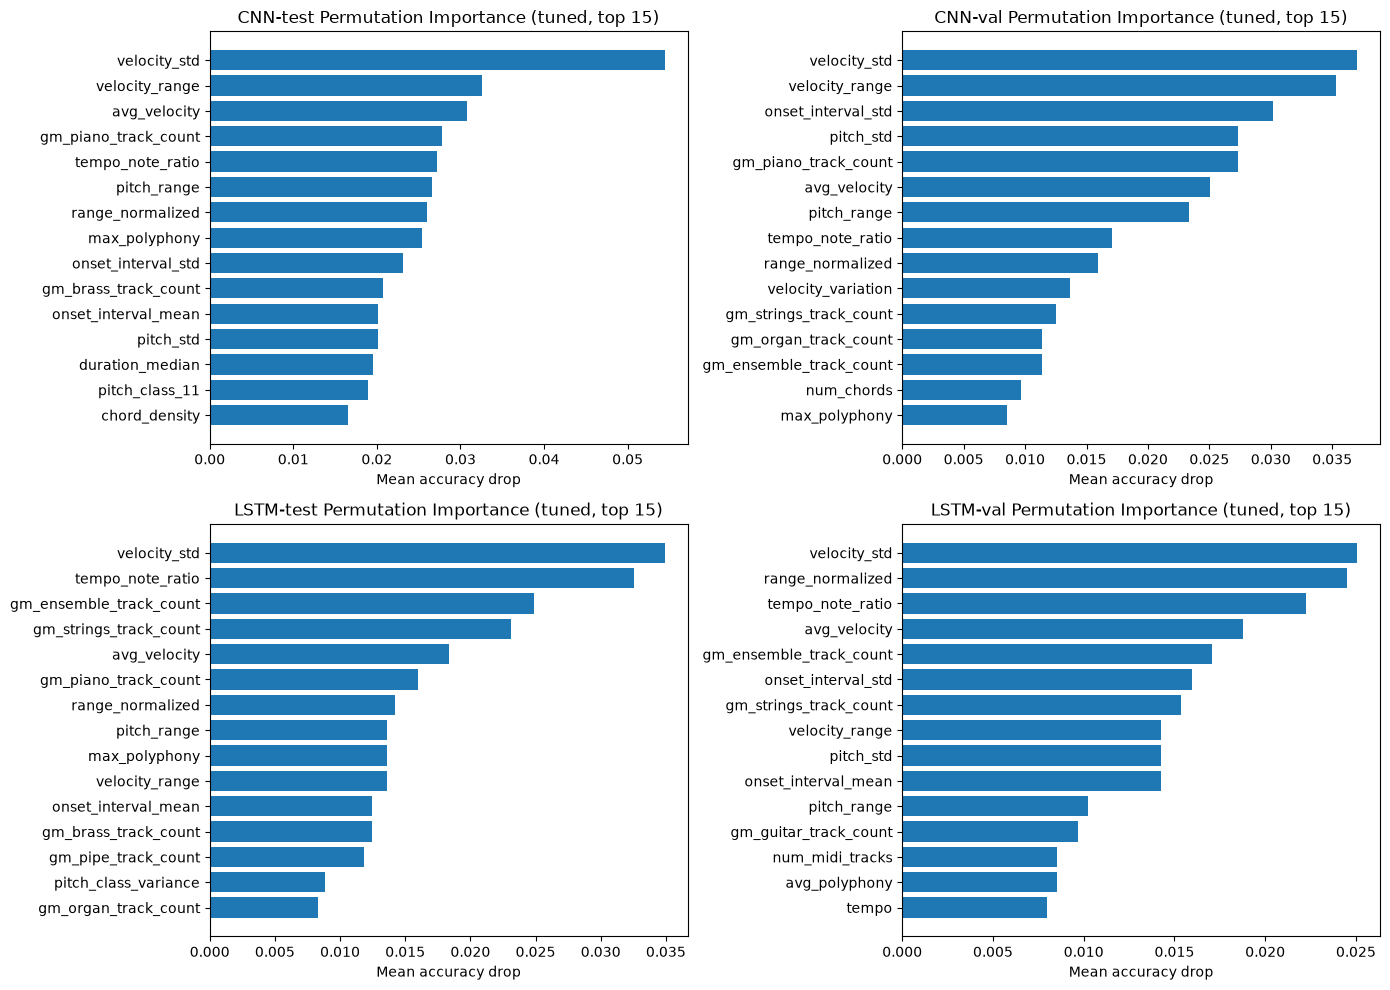

In [12]:
def permutation_importance_manual(model, X_2d, y_true, feature_names, reshape_fn, n_repeats=5, seed=SEED):
    rng = np.random.default_rng(seed)
    baseline_preds = model.predict(reshape_fn(X_2d), verbose=0).argmax(axis=1)
    baseline_acc = accuracy_score(y_true, baseline_preds)

    importances = np.zeros(len(feature_names))
    for col_idx in range(X_2d.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_2d.copy()
            X_permuted[:, col_idx] = rng.permutation(X_permuted[:, col_idx])
            permuted_preds = model.predict(reshape_fn(X_permuted), verbose=0).argmax(axis=1)
            drops.append(baseline_acc - accuracy_score(y_true, permuted_preds))
        importances[col_idx] = np.mean(drops)

    return pd.Series(importances, index=feature_names, name='importance').sort_values(ascending=False)

perm_importance = {
    'CNN-test': permutation_importance_manual(cnn_model, X_test_2d, y_test, feature_columns, cnn_reshape),
    'CNN-val': permutation_importance_manual(cnn_model, X_val_2d, y_val, feature_columns, cnn_reshape),
    'LSTM-test': permutation_importance_manual(lstm_model, X_test_2d, y_test, feature_columns, lstm_reshape),
    'LSTM-val': permutation_importance_manual(lstm_model, X_val_2d, y_val, feature_columns, lstm_reshape),
}

perm_importance_df = pd.DataFrame(perm_importance)
perm_importance_df.to_csv(OUTPUT_DIR / 'permutation_importance.csv')

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
layout = [
    ('CNN-test', axes[0, 0]), ('CNN-val', axes[0, 1]),
    ('LSTM-test', axes[1, 0]), ('LSTM-val', axes[1, 1]),
]
for name, ax in layout:
    top_features = perm_importance[name].head(TOP_N)
    ax.barh(top_features.index[::-1], top_features.values[::-1])
    ax.set(title=f'{name} Permutation Importance (tuned, top {TOP_N})', xlabel='Mean accuracy drop')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'permutation_importance_test_vs_val.png', dpi=150)
plt.show()

## 8. SHAP feature importance (supplementary)

In [13]:
N_BACKGROUND = 100
N_EXPLAIN = 100

try:
    import shap

    rng = np.random.default_rng(SEED)
    background_idx = rng.choice(X_train_2d.shape[0], size=min(N_BACKGROUND, X_train_2d.shape[0]), replace=False)
    explain_idx = rng.choice(X_test_2d.shape[0], size=min(N_EXPLAIN, X_test_2d.shape[0]), replace=False)

    def shap_summary(model, reshape_fn, model_name):
        background = reshape_fn(X_train_2d[background_idx])
        sample_2d = X_test_2d[explain_idx]
        sample = reshape_fn(sample_2d)
        try:
            explainer = shap.DeepExplainer(model, background)
            shap_values = explainer.shap_values(sample)
        except Exception as exc:
            print(f'DeepExplainer failed for {model_name} ({exc}); falling back to KernelExplainer.')
            predict_fn = lambda x: model.predict(reshape_fn(x), verbose=0)
            explainer = shap.KernelExplainer(predict_fn, X_train_2d[background_idx])
            shap_values = explainer.shap_values(sample_2d, nsamples=100)

        for class_idx, cls_name in enumerate(class_names):
            values = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[..., class_idx]
            values_2d = np.asarray(values).reshape(values.shape[0], -1)[:, :len(feature_columns)]
            plt.figure()
            shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)
            plt.title(f'{model_name} SHAP summary (tuned) — {cls_name}')
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f'shap_summary_{model_name.lower()}_{cls_name.lower()}.png', dpi=150)
            plt.close()
        print(f'Saved SHAP summary plots for {model_name}.')

    for model_name, model, reshape_fn in [('CNN', cnn_model, cnn_reshape), ('LSTM', lstm_model, lstm_reshape)]:
        try:
            shap_summary(model, reshape_fn, model_name)
        except Exception as exc:
            print(f'SHAP explanation failed for {model_name}, skipping: {exc}')

except ImportError:
    print("shap is not installed — run '%pip install shap' in a cell above, then restart the kernel and re-run this cell.")

C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_ten

C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


...


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


C:\Users\bsaig\AppData\Local\Temp\ipykernel_12636\1825342277.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)


Saved SHAP summary plots for LSTM.


## 9. Tuned vs. untuned comparison

Loads the freshly-updated baseline (untuned) notebook's saved metrics from `evaluation_outputs/`
(the combined-dataset, team-architecture run) and compares them side by side with this notebook's
tuned metrics. Run `Composer_Classification_Evaluation.ipynb` first if `evaluation_outputs/`
doesn't exist yet.

In [14]:
baseline_metrics_path = BASELINE_OUTPUT_DIR / 'test_vs_val_metrics.csv'
baseline_roc_path = BASELINE_OUTPUT_DIR / 'roc_auc_test_vs_val.csv'

if baseline_metrics_path.exists():
    base_df = pd.read_csv(baseline_metrics_path, index_col=0)
    base_df.index = [f'{idx} (untuned)' for idx in base_df.index]
    tuned_df = results_df.copy()
    tuned_df.index = [f'{idx} (tuned)' for idx in tuned_df.index]
    metrics_comparison_df = pd.concat([base_df, tuned_df]).sort_index()
    metrics_comparison_df.to_csv(OUTPUT_DIR / 'tuned_vs_untuned_metrics.csv')
    print('Accuracy / macro precision / recall / F1 — tuned vs. untuned:')
    display(metrics_comparison_df.style.format('{:.3f}'))
else:
    print(f'{baseline_metrics_path} not found — run Composer_Classification_Evaluation.ipynb first to enable this comparison.')
    metrics_comparison_df = None

if baseline_roc_path.exists():
    base_roc_df = pd.read_csv(baseline_roc_path, index_col=0)
    base_roc_df.index = [f'{idx} (untuned)' for idx in base_roc_df.index]
    tuned_roc_df = roc_auc_df.copy()
    tuned_roc_df.index = [f'{idx} (tuned)' for idx in tuned_roc_df.index]
    roc_comparison_df = pd.concat([base_roc_df, tuned_roc_df]).sort_index()
    roc_comparison_df.to_csv(OUTPUT_DIR / 'tuned_vs_untuned_roc_auc.csv')
    print('\nROC-AUC per class — tuned vs. untuned:')
    display(roc_comparison_df.style.format('{:.3f}'))
else:
    roc_comparison_df = None

Accuracy / macro precision / recall / F1 — tuned vs. untuned:


,accuracy,macro_precision,macro_recall,macro_f1
CNN-test (tuned),0.896,0.866,0.875,0.870
CNN-test (untuned),0.899,0.878,0.883,0.880
CNN-val (tuned),0.880,0.864,0.863,0.863
CNN-val (untuned),0.897,0.884,0.879,0.881
LSTM-test (tuned),0.879,0.858,0.859,0.857
LSTM-test (untuned),0.834,0.806,0.802,0.802
LSTM-val (tuned),0.889,0.878,0.872,0.875
LSTM-val (untuned),0.852,0.834,0.827,0.829



ROC-AUC per class — tuned vs. untuned:


,Bach,Beethoven,Chopin,Mozart,macro_auc
CNN-test (tuned),0.995,0.975,0.985,0.963,0.979
CNN-test (untuned),0.993,0.975,0.987,0.964,0.980
CNN-val (tuned),0.989,0.969,0.989,0.961,0.977
CNN-val (untuned),0.992,0.971,0.991,0.969,0.981
LSTM-test (tuned),0.992,0.970,0.971,0.968,0.975
LSTM-test (untuned),0.980,0.949,0.938,0.948,0.954
LSTM-val (tuned),0.990,0.973,0.994,0.970,0.982
LSTM-val (untuned),0.977,0.963,0.969,0.951,0.965


## 10. Summary

All comparison tables and plots are saved under `evaluation_outputs_tuned/`:

- `best_hyperparameters_cnn.json`, `best_hyperparameters_lstm.json`
- `test_vs_val_metrics.csv`, `confusion_matrices_test_vs_val.png`
- `loss_accuracy_curves_with_test.png`
- `roc_curves_test_vs_val.png`, `roc_auc_test_vs_val.csv`
- `permutation_importance_test_vs_val.png`, `permutation_importance.csv`
- `shap_summary_<model>_<composer>.png` (if SHAP succeeded)
- `tuned_vs_untuned_metrics.csv`, `tuned_vs_untuned_roc_auc.csv`

The prior single-dataset tuned run is preserved under
`evaluation_outputs_tuned_original_single_dataset/` for reference.

In [15]:
print('Saved tuned evaluation outputs to:', OUTPUT_DIR.resolve())
for path in sorted(OUTPUT_DIR.glob('*')):
    if path.is_file():
        print(' -', path.name)

Saved tuned evaluation outputs to: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\composer_model_project\evaluation_outputs_tuned
 - best_hyperparameters_cnn.json
 - best_hyperparameters_lstm.json
 - confusion_matrices_test_vs_val.png
 - loss_accuracy_curves_with_test.png
 - permutation_importance.csv
 - permutation_importance_test_vs_val.png
 - roc_auc_test_vs_val.csv
 - roc_curves_test_vs_val.png
 - shap_summary_cnn_bach.png
 - shap_summary_cnn_beethoven.png
 - shap_summary_cnn_chopin.png
 - shap_summary_cnn_mozart.png
 - shap_summary_lstm_bach.png
 - shap_summary_lstm_beethoven.png
 - shap_summary_lstm_chopin.png
 - shap_summary_lstm_mozart.png
 - test_vs_val_metrics.csv
 - tuned_vs_untuned_metrics.csv
 - tuned_vs_untuned_roc_auc.csv


## 11. Detailed evaluation analysis & discussion (tuned, combined dataset)

Interprets the tuning results above against the freshly-rebased baseline
(`Composer_Classification_Evaluation.ipynb`, combined dataset + team architecture, untuned). Numbers are
from this run's `evaluation_outputs_tuned/*.csv` and the baseline's `evaluation_outputs/*.csv`.

### 11.1 What the hyperparameter search found

| Hyperparameter | CNN — untuned | CNN — tuned | LSTM — untuned | LSTM — tuned |
|---|---:|---:|---:|---:|
| conv1 filters / LSTM units | 16 | **8** | 32 | **64** |
| conv2 filters | 32 | **48** | — | — |
| dense units | 32 | **48** | 32 | **32** |
| dropout | 0.30 | **0.30** | 0.30 / 0.20 | **0.30 / 0.15** |
| learning rate | 0.005 | **0.01** | 0.003 | **0.01** |

Same pattern as the previous tuning round on the old single dataset: **both models converged on a higher
learning rate** (0.01, roughly 2–3x the hand-set values), and **LSTM capacity doubled** (32→64 units)
while CNN's first conv layer shrank (16→8). This is the second time this exact LSTM-units-should-be-larger
signal has shown up independently (previously on the old dataset/old architecture, now again on the new
one) — a reasonably strong hint that 32 units under-fits this LSTM's capacity regardless of dataset
version.

### 11.2 Tuned vs. untuned — accuracy / macro F1

| Model | Split | Accuracy (untuned → tuned) | Macro F1 (untuned → tuned) |
|---|---|---|---|
| CNN  | Test       | 0.899 → **0.896** (−0.003) | 0.880 → **0.870** (−0.010) |
| CNN  | Validation | 0.897 → **0.880** (−0.017) | 0.881 → **0.863** (−0.018) |
| LSTM | Test       | 0.834 → **0.879** (+0.045) | 0.802 → **0.857** (+0.055) |
| LSTM | Validation | 0.852 → **0.889** (+0.037) | 0.829 → **0.875** (+0.046) |

**LSTM tuning is a clean, unambiguous win** — improved on both test and validation, by a similar margin on
each (not a validation-only artifact). Combined with the doubled LSTM unit count, tuned LSTM (test macro F1
0.857) is now much closer to CNN (0.870) than the untuned models were (0.802 vs. 0.880) — the
architecture gap that Section 9.5 of the baseline notebook discussed has narrowed further.

**CNN tuning did not help this time — on either split.** Unlike the earlier tuning round on the old
dataset (where the tuned CNN improved on validation but got *worse* on test — a validation-overfitting
signature), here the tuned CNN is slightly worse on *both* test (−0.010 macro F1) and validation
(−0.018 macro F1). That rules out validation-overfitting as the explanation this time; the more likely
read is simply that the team's hand-chosen CNN configuration (16/32 filters, dense 32, lr 0.005) was
already a strong choice for this architecture and dataset, and a 20-epoch-budget Hyperband search over this
particular grid didn't find anything better. **Across both tuning rounds now, the consistent, replicated
conclusion is: tune the LSTM, keep the CNN's original hyperparameters.**

### 11.3 ROC-AUC — tuned vs. untuned

| Model | Split | Macro AUC (untuned → tuned) |
|---|---|---|
| CNN  | Test       | 0.980 → **0.979** (flat) |
| CNN  | Validation | 0.981 → **0.977** (−0.004) |
| LSTM | Test       | 0.954 → **0.975** (+0.022) |
| LSTM | Validation | 0.965 → **0.982** (+0.017) |

Consistent with §11.2: CNN's ranking quality is essentially unchanged by tuning (small dip, not
meaningful), while LSTM's improves on both splits — reinforcing that the LSTM gain is real, not noise.

### 11.4 Feature importance after tuning

Top permutation-importance features, tuned models (new combined dataset):

| Rank | CNN (test) | CNN (val) | LSTM (test) | LSTM (val) |
|---|---|---|---|---|
| 1 | velocity_std | velocity_std | velocity_std | velocity_std |
| 2 | velocity_range | velocity_range | tempo_note_ratio | range_normalized |
| 3 | avg_velocity | onset_interval_std | gm_ensemble_track_count | tempo_note_ratio |
| 4 | gm_piano_track_count | gm_piano_track_count | gm_strings_track_count | avg_velocity |

`velocity_std` is now the single most important feature for **both** models on **every** split — an even
stronger version of the shift already noted in the untuned baseline notebook's §9.7 (both models leaning on
velocity/timing features more than pitch statistics after the dataset rebase). This strengthens that
notebook's flagged concern: it's worth checking whether velocity characteristics differ systematically by
*MIDI source* (piano-midi.de vs. Hugging Face mirrors vs. Kaggle sets, etc.) rather than purely by composer,
since a feature this dominant deserves scrutiny before treating it as confirmed musical signal.

### 11.5 Key takeaway

For **LSTM**: tune it. Both tuning rounds on both dataset versions now agree — more LSTM units (64 instead
of 32) and a higher learning rate genuinely help, on the untouched test set, not just validation.

For **CNN**: the team's hand-set hyperparameters remain hard to beat with this search space/budget, on
both the old and new dataset. This is a useful, twice-replicated negative result rather than a fluke — it
suggests further CNN gains, if wanted, are more likely to come from a materially different search space
(e.g. deeper networks, different regularization) or more search budget than from re-running this same
Hyperband sweep again.

### 11.6 Limitations

- Same caveats as the baseline notebook's §9.9 (data+architecture confounded in the rebase, uneven new-data
  sources across composers, bounded SHAP sample size) apply unchanged here.
- The Hyperband search objective was `val_accuracy` on the `dev` split; §11.2's CNN result (worse on both
  splits, not just test) is actually a cleaner outcome than the previous round's validation-only regression
  — it's a genuine "search didn't find anything better" rather than a "search overfit to validation" case,
  and should be read that way rather than as evidence the search process itself is broken.